In [1]:
import os
import time
import json
import copy
import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

# Импорт метрик для экспериментального сравнения
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, precision_recall_curve, classification_report

# Импорт модулей глубокого обучения PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import models, transforms

# Импорт индикатора прогресса
from tqdm.auto import tqdm

C:\Users\DAN\anaconda3\envs\torch_gpu\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
conda install pandas matplotlib seaborn scikit-learn -y

In [ ]:
conda install pytorch-cpu torchvision-cpu -c pytorch

In [ ]:
!pip install torch torchvision

In [ ]:
!pip install seaborn

In [2]:
# Фиксация генераторов псевдослучайных чисел для воспроизводимости экспериментов
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [3]:
# Определение доступного вычислительного устройства
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Вычислительное устройство инициализировано: {device}")

Вычислительное устройство инициализировано: cuda


In [4]:
# Включаем оптимизацию тензорных ядер (TF32) для видеокарт Ampere/Ada/Blackwell
if device.type == 'cuda':
    torch.set_float32_matmul_precision('high')
    print("Матричное умножение Tensor Cores (TF32) переведено в высокопроизводительный режим 'high'")

Матричное умножение Tensor Cores (TF32) переведено в высокопроизводительный режим 'high'


In [5]:
# Вспомогательная функция для обратной нормализации тензоров в картинку (для графиков)
def unnormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1).to(tensor.device)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1).to(tensor.device)
    tensor = tensor * std + mean
    return torch.clamp(tensor, 0, 1)

In [ ]:
import sys
!{sys.executable} -m pip install roboflow pandas matplotlib seaborn scikit-learn


In [ ]:
!pip install roboflow

In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="OKwu3x0mbieC286hD6Og")
project = rf.workspace("vanshika-fiktf").project("industrial-defect-detection-y5uul")
version = project.version(1)
dataset = version.download("yolov8")
                

In [ ]:
import os
import cv2
import shutil


yolo_dataset_path = dataset.location
output_base_path = './dataset/y5uul/'

# Классы согласно проекту Roboflow
class_mapping = {0: "Crack", 1: "Defect", 2: "Rust", 3: "Leak"}

def process_split(input_split, output_split):
    input_images_dir = os.path.join(yolo_dataset_path, input_split, 'images')
    input_labels_dir = os.path.join(yolo_dataset_path, input_split, 'labels')
    
    if not os.path.exists(input_images_dir):
        return

    for img_name in os.listdir(input_images_dir):
        if not img_name.endswith(('.jpg', '.jpeg', '.png')):
            continue
            
        img_path = os.path.join(input_images_dir, img_name)
        
        # Распаковываем кортеж на две переменные
        name_without_ext, ext = os.path.splitext(img_name)
        label_name = name_without_ext + '.txt'
        label_path = os.path.join(input_labels_dir, label_name)
        
        img = cv2.imread(img_path)
        if img is None:
            continue
        h_img, w_img, _ = img.shape

        # Если текстового файла нет или он пуст - дефектов нет, класс Normal
        if not os.path.exists(label_path) or os.path.getsize(label_path) == 0:
            out_dir = os.path.join(output_base_path, output_split, "Normal")
            os.makedirs(out_dir, exist_ok=True)
            shutil.copy(img_path, os.path.join(out_dir, img_name))
            continue

        # Читаем координаты и вырезаем дефекты
        with open(label_path, 'r') as f:
            lines = f.readlines()
            
        for idx, line in enumerate(lines):
            parts = line.strip().split()
            if len(parts) >= 5:
                class_id_str, x_center_str, y_center_str, w_str, h_str = parts[:5]
                
                class_id = int(class_id_str)
                class_name = class_mapping.get(class_id, "Unknown")
                
                # Координаты YOLO (от 0 до 1) переводим в пиксели изображения
                x_center = float(x_center_str)
                y_center = float(y_center_str)
                w = float(w_str)
                h = float(h_str)
                
                x1 = max(0, int((x_center - w / 2) * w_img))
                y1 = max(0, int((y_center - h / 2) * h_img))
                x2 = min(w_img, int((x_center + w / 2) * w_img))
                y2 = min(h_img, int((y_center + h / 2) * h_img))
                
                cropped_img = img[y1:y2, x1:x2]
                
                # Пропускаем ошибочные пустые обрезы
                if cropped_img.size == 0:
                    continue
                    
                out_dir = os.path.join(output_base_path, output_split, class_name)
                os.makedirs(out_dir, exist_ok=True)
                
                out_img_name = f"{name_without_ext}_crop_{idx}.jpg"
                cv2.imwrite(os.path.join(out_dir, out_img_name), cropped_img)


if os.path.exists(output_base_path):
    shutil.rmtree(output_base_path)
os.makedirs(output_base_path, exist_ok=True)


process_split('train', 'train')
process_split('valid', 'train')

process_split('test', 'test')

print("Структура папок успешно сформирована в директории:", output_base_path)

In [6]:
# Определение трансформаций и архитектуры Dataset

from tqdm.auto import tqdm
from PIL import Image
import os

CLASSES_STR = ['Crack', 'Defect', 'Rust', 'Leak', 'Normal']

train_transform_clf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class IndustrialDataset(Dataset):
    def __init__(self, root_dir, transform=None, is_anomaly_task=False, anomaly_train=False, max_samples_per_class=1500):
        self.root_dir = root_dir
        self.transform = transform
        self.is_anomaly_task = is_anomaly_task
        
        self.classes = CLASSES_STR
        self.filepaths, self.labels = [], []
        
        for label_idx, class_name in enumerate(self.classes):
            class_dir = os.path.join(root_dir, class_name)
            if not os.path.isdir(class_dir): continue
                
            # Получаем список всех картинок дефекта
            valid_files = [f for f in os.listdir(class_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            
            if not (is_anomaly_task and anomaly_train): 
                valid_files = valid_files[:max_samples_per_class]

            for img_name in valid_files:
                if is_anomaly_task and anomaly_train and class_name != 'Normal':
                    continue
                self.filepaths.append(os.path.join(class_dir, img_name))
                self.labels.append(label_idx)

        self.cached_images = []
        print(f"\nЗагрузка {len(self.filepaths)} изображений в оперативную память...")
        for path in tqdm(self.filepaths, desc=f"Кэширование {os.path.basename(root_dir)}", leave=False):
            img = Image.open(path).convert("RGB")
            img = img.resize((224, 224)) 
            self.cached_images.append(img)

    def __len__(self): 
        return len(self.filepaths)
        
    def __getitem__(self, idx):

        image = self.cached_images[idx]
        return self.transform(image) if self.transform else image, self.labels[idx]

class DatasetWrapper(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
    def __getitem__(self, i):
        x, y = self.subset[i]
        return self.transform(x) if self.transform else x, y
    def __len__(self): 
        return len(self.subset)

In [7]:
# Разделение данных и создание DataLoaders

# Загрузка всего тренировочного датасета
full_clf_dataset = IndustrialDataset(root_dir='./dataset/y5uul/train', transform=None)

# Разбиение на обучающую и валидационную выборку (80% / 20%)
train_size = int(0.8 * len(full_clf_dataset)) 
val_size = len(full_clf_dataset) - train_size

train_ds, val_ds = random_split(full_clf_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42))


train_dataset = DatasetWrapper(train_ds, train_transform_clf)
val_dataset = DatasetWrapper(val_ds, val_test_transform)

# Тестовая выборка из отдельной папки
test_dataset_raw = IndustrialDataset(root_dir='./dataset/y5uul/test', transform=None)
test_dataset = DatasetWrapper(test_dataset_raw, val_test_transform)

BATCH_SIZE = 32 
NUM_WORKERS = 0


train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

# Специфичный загрузчик для обучения автоэнкодера (только нормальные детали)
cae_train_raw = IndustrialDataset('./dataset/y5uul/train', transform=None, is_anomaly_task=True, anomaly_train=True)
cae_train_dataset = DatasetWrapper(cae_train_raw, train_transform_clf)
cae_train_loader = DataLoader(cae_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)


Загрузка 7500 изображений в оперативную память...



Загрузка 4771 изображений в оперативную память...



Загрузка 9324 изображений в оперативную память...


In [8]:
# Архитектура 1 - ResNet-50 с Grad-CAM

class ResNet50GradCAM(nn.Module):
    def __init__(self, num_classes=5):
        super(ResNet50GradCAM, self).__init__()
        self.model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)
        self.gradients, self.activations = None, None
        
        target_layer = self.model.layer4[-1].conv3
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output): self.activations = output
    def save_gradient(self, module, grad_input, grad_output): self.gradients = grad_output[0]
    def forward(self, x): return self.model(x)

    def generate_heatmap(self, x, class_idx=None):
        self.eval()
        logits = self(x)
        if class_idx is None: class_idx = torch.argmax(logits, dim=1).item()
            
        self.zero_grad()
        one_hot = torch.zeros_like(logits)
        one_hot[0][class_idx] = 1.0
        logits.backward(gradient=one_hot, retain_graph=True)
        
        gradients = self.gradients.detach()
        activations = self.activations.detach()
        pooled_gradients = torch.mean(gradients, dim=[0, 2, 3])
        for i in range(activations.size(1)): activations[:, i, :, :] *= pooled_gradients[i]
            
        heatmap = torch.mean(activations, dim=1).squeeze()
        heatmap = F.relu(heatmap)
        heatmap /= torch.max(heatmap) + 1e-8
        return heatmap.cpu().numpy(), class_idx

In [9]:
# Архитектуры 2 и 3 - EfficientNet-B3 и ViT-Base

class EfficientNetB3Model(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.model = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1)
        self.model.classifier[1] = nn.Linear(self.model.classifier[1].in_features, num_classes)
    def forward(self, x): return self.model(x)

class ViTBaseModel(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.model = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
        self.model.heads.head = nn.Linear(self.model.heads.head.in_features, num_classes)
    def forward(self, x): return self.model(x)

In [10]:
# Архитектура 4 - Сверточный Автоэнкодер (CAE)

class ConvAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, 2, 1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.Conv2d(32, 64, 3, 2, 1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.Conv2d(64, 128, 3, 2, 1), nn.BatchNorm2d(128), nn.ReLU(True),
            nn.Conv2d(128, 256, 3, 2, 1), nn.BatchNorm2d(256), nn.ReLU(True)
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 3, 2, 1, 1), nn.BatchNorm2d(128), nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 3, 2, 1, 1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, 3, 2, 1, 1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.ConvTranspose2d(32, 3, 3, 2, 1, 1), nn.Sigmoid() 
        )
    def forward(self, x): return self.decoder(self.encoder(x))

# Вычисление MSE ошибки по пикселям для визуализации тепловой карты аномалий
def compute_cae_heatmap(original, reconstructed):
    squared_diff = (original - reconstructed) ** 2
    heatmap = torch.mean(squared_diff, dim=1).squeeze().detach().cpu().numpy()
    if heatmap.ndim == 2: heatmap = np.expand_dims(heatmap, axis=0) # Корректировка для батча=1
    return heatmap

In [11]:
# Архитектура 5 - MobileNetV3
class MobileNetV3Model(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.model = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.IMAGENET1K_V1)
        self.model.classifier[3] = nn.Linear(self.model.classifier[3].in_features, num_classes)
    def forward(self, x): return self.model(x)

In [12]:
# Циклы обучения с сохранением истории для построения графиков

def train_classification_model(model, train_loader, val_loader, model_path, num_epochs=10):
    print(f"\n--- Обучение {model.__class__.__name__} ---")
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    

    optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)
    
    scaler = torch.amp.GradScaler('cuda') if device.type == 'cuda' else None
    best_val_acc, history = 0.0, {'train_loss': [], 'val_acc': []}
    
    for epoch in range(num_epochs):
        model.train(); running_loss = 0.0
        for batch_idx, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
                loss = criterion(model(inputs), labels)
            if scaler: scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
            else: loss.backward(); optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            print(f"\rEpoch {epoch+1}/{num_epochs} | Батч {batch_idx+1}/{len(train_loader)} | Loss: {loss.item():.4f}", end="")
            
        scheduler.step() # Шаг планировщика обучения
        
        epoch_train_loss = running_loss / len(train_loader.dataset)
        model.eval(); correct, total = 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                correct += torch.sum(torch.max(model(inputs.to(device)), 1)[1] == labels.to(device)).item()
                total += labels.size(0)
        epoch_val_acc = correct / total
        history['train_loss'].append(epoch_train_loss); history['val_acc'].append(epoch_val_acc)
        print(f"\rEpoch {epoch+1}/{num_epochs} | Train Loss: {epoch_train_loss:.4f} | Val Acc: {epoch_val_acc:.4f} | Завершено!       ")
        if epoch_val_acc >= best_val_acc: best_val_acc = epoch_val_acc; torch.save(model.state_dict(), model_path)
            
    model.load_state_dict(torch.load(model_path)); return model, history

def train_cae_model(model, train_loader, model_path, num_epochs=10):
    print(f"\n--- Обучение CAE ---")
    model = model.to(device)
    criterion, optimizer = nn.MSELoss(), optim.Adam(model.parameters(), lr=1e-3)
    scaler = torch.amp.GradScaler('cuda') if device.type == 'cuda' else None
    history = {'train_loss': []}
    
    for epoch in range(num_epochs):
        model.train(); running_loss = 0.0
        for batch_idx, (inputs, _) in enumerate(train_loader):
            inputs = inputs.to(device); optimizer.zero_grad()
            with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
                loss = criterion(model(inputs), inputs)
            if scaler: scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
            else: loss.backward(); optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            print(f"\rEpoch {epoch+1}/{num_epochs} | Батч {batch_idx+1}/{len(train_loader)} | MSE: {loss.item():.4f}", end="")
            
        epoch_train_loss = running_loss / len(train_loader.dataset)
        history['train_loss'].append(epoch_train_loss)
        print(f"\rEpoch {epoch+1}/{num_epochs} | Reconstruction Loss (MSE): {epoch_train_loss:.4f} | Завершено!               ")
        
    torch.save(model.state_dict(), model_path); return model, history

In [13]:
# ЗАПУСК ОБУЧЕНИЯ
import gc

EPOCHS = 10
histories = {}

In [14]:
# 1. Обучение ResNet-50
resnet_model = ResNet50GradCAM(5)
resnet_model, histories['ResNet50'] = train_classification_model(resnet_model, train_loader, val_loader, "resnet50_best.pth", EPOCHS)
del resnet_model           
gc.collect()               
torch.cuda.empty_cache()   


--- Обучение ResNet50GradCAM ---
Epoch 1/10 | Train Loss: 0.4842 | Val Acc: 0.9180 | Завершено!       
Epoch 2/10 | Train Loss: 0.3107 | Val Acc: 0.8800 | Завершено!       
Epoch 3/10 | Train Loss: 0.2122 | Val Acc: 0.9200 | Завершено!       
Epoch 4/10 | Train Loss: 0.1737 | Val Acc: 0.9180 | Завершено!       
Epoch 5/10 | Train Loss: 0.1193 | Val Acc: 0.9587 | Завершено!       
Epoch 6/10 | Train Loss: 0.0730 | Val Acc: 0.9547 | Завершено!       
Epoch 7/10 | Train Loss: 0.0488 | Val Acc: 0.9673 | Завершено!       
Epoch 8/10 | Train Loss: 0.0314 | Val Acc: 0.9700 | Завершено!       
Epoch 9/10 | Train Loss: 0.0154 | Val Acc: 0.9747 | Завершено!       
Epoch 10/10 | Train Loss: 0.0085 | Val Acc: 0.9740 | Завершено!       


In [15]:
# 2. Обучение EfficientNet-B3
effnet_model = EfficientNetB3Model(5)
effnet_model, histories['EfficientNet'] = train_classification_model(effnet_model, train_loader, val_loader, "effnet_b3_best.pth", EPOCHS)
del effnet_model
gc.collect()
torch.cuda.empty_cache()


--- Обучение EfficientNetB3Model ---
Epoch 1/10 | Train Loss: 0.4241 | Val Acc: 0.9713 | Завершено!       
Epoch 2/10 | Train Loss: 0.1128 | Val Acc: 0.9653 | Завершено!       
Epoch 3/10 | Train Loss: 0.0684 | Val Acc: 0.9747 | Завершено!       
Epoch 4/10 | Train Loss: 0.0561 | Val Acc: 0.9793 | Завершено!       
Epoch 5/10 | Train Loss: 0.0310 | Val Acc: 0.9807 | Завершено!       
Epoch 6/10 | Train Loss: 0.0182 | Val Acc: 0.9813 | Завершено!       
Epoch 7/10 | Train Loss: 0.0159 | Val Acc: 0.9840 | Завершено!       
Epoch 8/10 | Train Loss: 0.0115 | Val Acc: 0.9833 | Завершено!       
Epoch 9/10 | Train Loss: 0.0096 | Val Acc: 0.9847 | Завершено!       
Epoch 10/10 | Train Loss: 0.0093 | Val Acc: 0.9867 | Завершено!       


In [16]:
# 3. Обучение ViT-Base
vit_model = ViTBaseModel(5)
vit_model, histories['ViT'] = train_classification_model(vit_model, train_loader, val_loader, "vit_base_best.pth", EPOCHS)
del vit_model
gc.collect()
torch.cuda.empty_cache()


--- Обучение ViTBaseModel ---
Epoch 1/10 | Train Loss: 0.8032 | Val Acc: 0.7667 | Завершено!       
Epoch 2/10 | Train Loss: 0.4612 | Val Acc: 0.8547 | Завершено!       
Epoch 3/10 | Train Loss: 0.3719 | Val Acc: 0.9007 | Завершено!       
Epoch 4/10 | Train Loss: 0.2472 | Val Acc: 0.9193 | Завершено!       
Epoch 5/10 | Train Loss: 0.1882 | Val Acc: 0.9180 | Завершено!       
Epoch 6/10 | Train Loss: 0.1150 | Val Acc: 0.9207 | Завершено!       
Epoch 7/10 | Train Loss: 0.0668 | Val Acc: 0.9480 | Завершено!       
Epoch 8/10 | Train Loss: 0.0277 | Val Acc: 0.9540 | Завершено!       
Epoch 9/10 | Train Loss: 0.0118 | Val Acc: 0.9633 | Завершено!       
Epoch 10/10 | Train Loss: 0.0066 | Val Acc: 0.9700 | Завершено!       


In [17]:
# 4. Обучение Conv Autoencoder
cae_model = ConvAutoencoder()
cae_model, histories['CAE'] = train_cae_model(cae_model, cae_train_loader, "cae_best.pth", EPOCHS)
del cae_model
gc.collect()
torch.cuda.empty_cache()


--- Обучение CAE ---
Epoch 1/10 | Reconstruction Loss (MSE): 0.9617 | Завершено!               
Epoch 2/10 | Reconstruction Loss (MSE): 0.8591 | Завершено!               
Epoch 3/10 | Reconstruction Loss (MSE): 0.8521 | Завершено!               
Epoch 4/10 | Reconstruction Loss (MSE): 0.8411 | Завершено!               
Epoch 5/10 | Reconstruction Loss (MSE): 0.8489 | Завершено!               
Epoch 6/10 | Reconstruction Loss (MSE): 0.8439 | Завершено!               
Epoch 7/10 | Reconstruction Loss (MSE): 0.8400 | Завершено!               
Epoch 8/10 | Reconstruction Loss (MSE): 0.8379 | Завершено!               
Epoch 9/10 | Reconstruction Loss (MSE): 0.8394 | Завершено!               
Epoch 10/10 | Reconstruction Loss (MSE): 0.8342 | Завершено!               


In [18]:
# 5. Обучение MobileNetV3
mobilenet_model = MobileNetV3Model(5)
mobilenet_model, histories['MobileNet'] = train_classification_model(mobilenet_model, train_loader, val_loader, "mobilenet_v3_best.pth", EPOCHS)
del mobilenet_model
gc.collect()
torch.cuda.empty_cache()


--- Обучение MobileNetV3Model ---
Epoch 1/10 | Train Loss: 0.3543 | Val Acc: 0.9353 | Завершено!       
Epoch 2/10 | Train Loss: 0.1202 | Val Acc: 0.9660 | Завершено!       
Epoch 3/10 | Train Loss: 0.0701 | Val Acc: 0.9567 | Завершено!       
Epoch 4/10 | Train Loss: 0.0462 | Val Acc: 0.9680 | Завершено!       
Epoch 5/10 | Train Loss: 0.0321 | Val Acc: 0.9680 | Завершено!       
Epoch 6/10 | Train Loss: 0.0172 | Val Acc: 0.9753 | Завершено!       
Epoch 7/10 | Train Loss: 0.0099 | Val Acc: 0.9780 | Завершено!       
Epoch 8/10 | Train Loss: 0.0073 | Val Acc: 0.9787 | Завершено!       
Epoch 9/10 | Train Loss: 0.0046 | Val Acc: 0.9813 | Завершено!       
Epoch 10/10 | Train Loss: 0.0052 | Val Acc: 0.9813 | Завершено!       


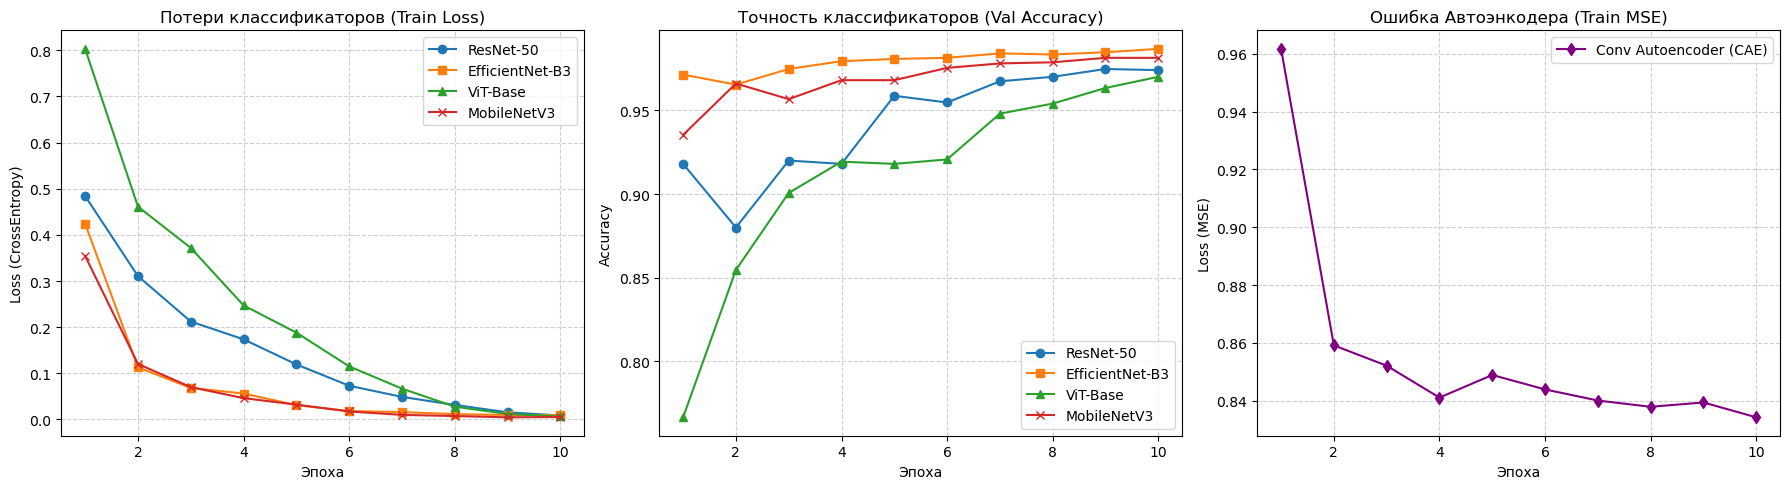

In [19]:
# Построение графиков по эпохам
plt.figure(figsize=(18, 5))
epochs_range = range(1, EPOCHS + 1)

# График 1: Функция потерь классификаторов (4 Линии)
plt.subplot(1, 3, 1)
plt.plot(epochs_range, histories['ResNet50']['train_loss'], label='ResNet-50', marker='o')
plt.plot(epochs_range, histories['EfficientNet']['train_loss'], label='EfficientNet-B3', marker='s')
plt.plot(epochs_range, histories['ViT']['train_loss'], label='ViT-Base', marker='^')
plt.plot(epochs_range, histories['MobileNet']['train_loss'], label='MobileNetV3', marker='x')
plt.title('Потери классификаторов (Train Loss)')
plt.xlabel('Эпоха'); plt.ylabel('Loss (CrossEntropy)')
plt.grid(True, linestyle='--', alpha=0.6); plt.legend()

# График 2: Точность классификаторов (4 Линии)
plt.subplot(1, 3, 2)
plt.plot(epochs_range, histories['ResNet50']['val_acc'], label='ResNet-50', marker='o')
plt.plot(epochs_range, histories['EfficientNet']['val_acc'], label='EfficientNet-B3', marker='s')
plt.plot(epochs_range, histories['ViT']['val_acc'], label='ViT-Base', marker='^')
plt.plot(epochs_range, histories['MobileNet']['val_acc'], label='MobileNetV3', marker='x')
plt.title('Точность классификаторов (Val Accuracy)')
plt.xlabel('Эпоха'); plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.6); plt.legend()

# График 3: Ошибка CAE (1 Линия)
plt.subplot(1, 3, 3)
plt.plot(epochs_range, histories['CAE']['train_loss'], label='Conv Autoencoder (CAE)', color='purple', marker='d')
plt.title('Ошибка Автоэнкодера (Train MSE)')
plt.xlabel('Эпоха'); plt.ylabel('Loss (MSE)')
plt.grid(True, linestyle='--', alpha=0.6); plt.legend()

plt.tight_layout()
plt.show()

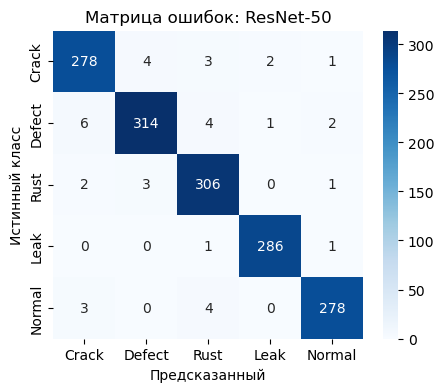

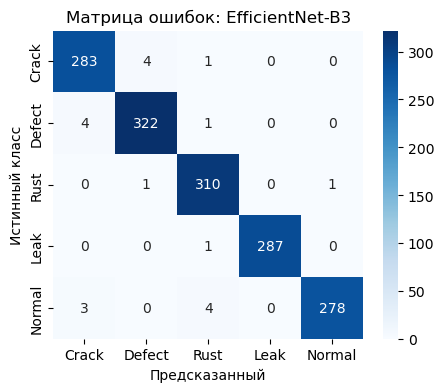

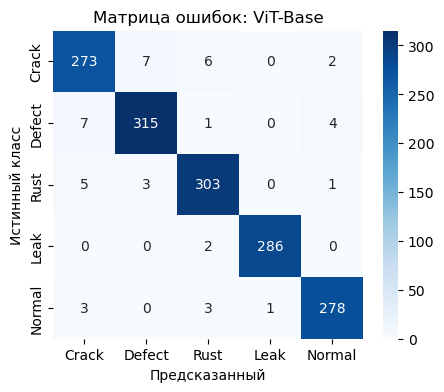

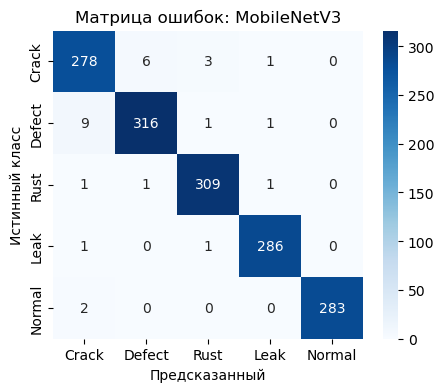


             ИТОГОВАЯ ТАБЛИЦА СРАВНЕНИЯ АРХИТЕКТУР
                  Accuracy  Precision  Recall  F1-score
ResNet-50            0.975      0.975   0.975     0.975
EfficientNet-B3      0.987      0.987   0.987     0.987
ViT-Base             0.970      0.970   0.970     0.970
MobileNetV3          0.981      0.981   0.981     0.981
Conv Autoencoder     0.809      0.405   0.500     0.447


In [41]:
# Сравнение метрик и детальная проверка моделей
def evaluate_classifier(model_class, model_path, title):
    import torch
    import os
    from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
    
    if not os.path.exists(model_path):
        return None
        
    model = model_class(num_classes=5).to(device)
    model.load_state_dict(torch.load(model_path))
    model.eval()
    
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in val_loader:
            _, preds = torch.max(model(inputs.to(device)), 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    acc = accuracy_score(all_labels, all_preds)
    prec, rec, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted', zero_division=0)
    
    cm = confusion_matrix(all_labels, all_preds, labels=[0, 1, 2, 3, 4])
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES_STR, yticklabels=CLASSES_STR)
    plt.title(f'Матрица ошибок: {title}')
    plt.ylabel('Истинный класс'); plt.xlabel('Предсказанный')
    plt.savefig(f'cm_{title}.png')
    plt.show() # <-- ТЕПЕРЬ МАТРИЦА ОШИБОК ВЫВОДИТСЯ НА ЭКРАН ПЕРЕД ТАБЛИЦЕЙ!
    
    del model; gc.collect(); torch.cuda.empty_cache()
    return {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1-score": f1}

results = {}
for name, cls, path in [
    ('ResNet-50', ResNet50GradCAM, "resnet50_best.pth"),
    ('EfficientNet-B3', EfficientNetB3Model, "effnet_b3_best.pth"),
    ('ViT-Base', ViTBaseModel, "vit_base_best.pth"),
    ('MobileNetV3', MobileNetV3Model, "mobilenet_v3_best.pth")
]:
    res = evaluate_classifier(cls, path, name)
    if res: results[name] = res

# Оценка CAE
if os.path.exists("cae_best.pth"):
    from sklearn.metrics import precision_recall_curve, precision_recall_fscore_support, accuracy_score
    cae_eval_model = ConvAutoencoder().to(device)
    cae_eval_model.load_state_dict(torch.load("cae_best.pth")); cae_eval_model.eval()
    
    val_anomaly_scores = []
    val_labels = []

    with torch.no_grad():
        for inputs, labels in val_loader: 
            inputs = inputs.to(device)
            recons = cae_eval_model(inputs)
            
            squared_diff = ((inputs - recons)**2).view(inputs.size(0), -1)
            top_k = max(1, int(squared_diff.size(1) * 0.05))
            anomaly_scores = torch.topk(squared_diff, top_k, dim=1)[0].mean(dim=1).cpu().numpy()
            
            val_anomaly_scores.extend(anomaly_scores)
            val_labels.extend([0 if l.item() == 4 else 1 for l in labels])

    precision, recall, thresholds = precision_recall_curve(val_labels, val_anomaly_scores)
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
    
    best_idx = np.argmax(f1_scores)
    best_thresh = thresholds[best_idx] if best_idx < len(thresholds) else thresholds[-1]
            
    c_preds = [1 if score > best_thresh else 0 for score in val_anomaly_scores]
    
    acc = accuracy_score(val_labels, c_preds)
    prec, rec, f1, _ = precision_recall_fscore_support(val_labels, c_preds, average='macro', zero_division=0)
    
    results['Conv Autoencoder'] = {
        "Accuracy": acc, "Precision": prec, "Recall": rec, "F1-score": f1
    }

    del cae_eval_model; gc.collect(); torch.cuda.empty_cache()
else:
    print("\n[WARNING] Файл весов cae_best.pth не найден! Оценка Автоэнкодера пропущена.")

print("\n             ИТОГОВАЯ ТАБЛИЦА СРАВНЕНИЯ АРХИТЕКТУР")
metrics_df = pd.DataFrame(results).T.round(3)
print(metrics_df.to_string())

In [28]:
import cv2

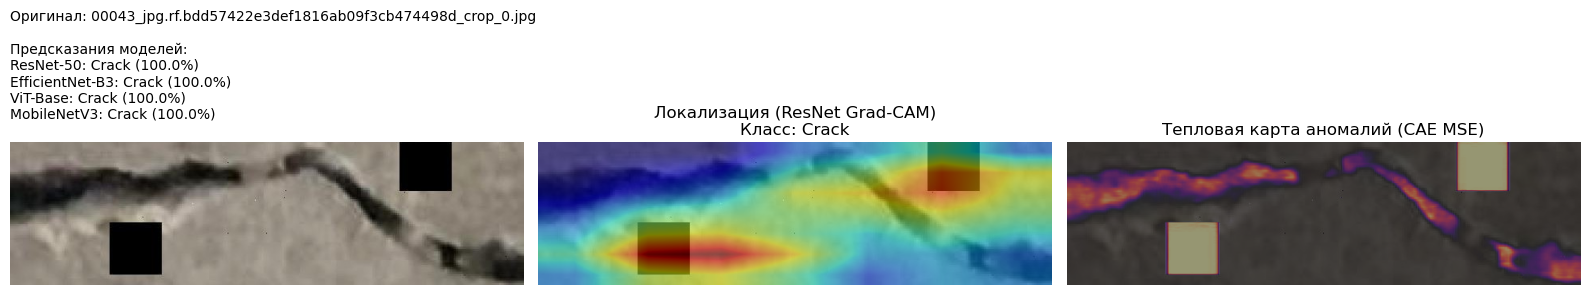

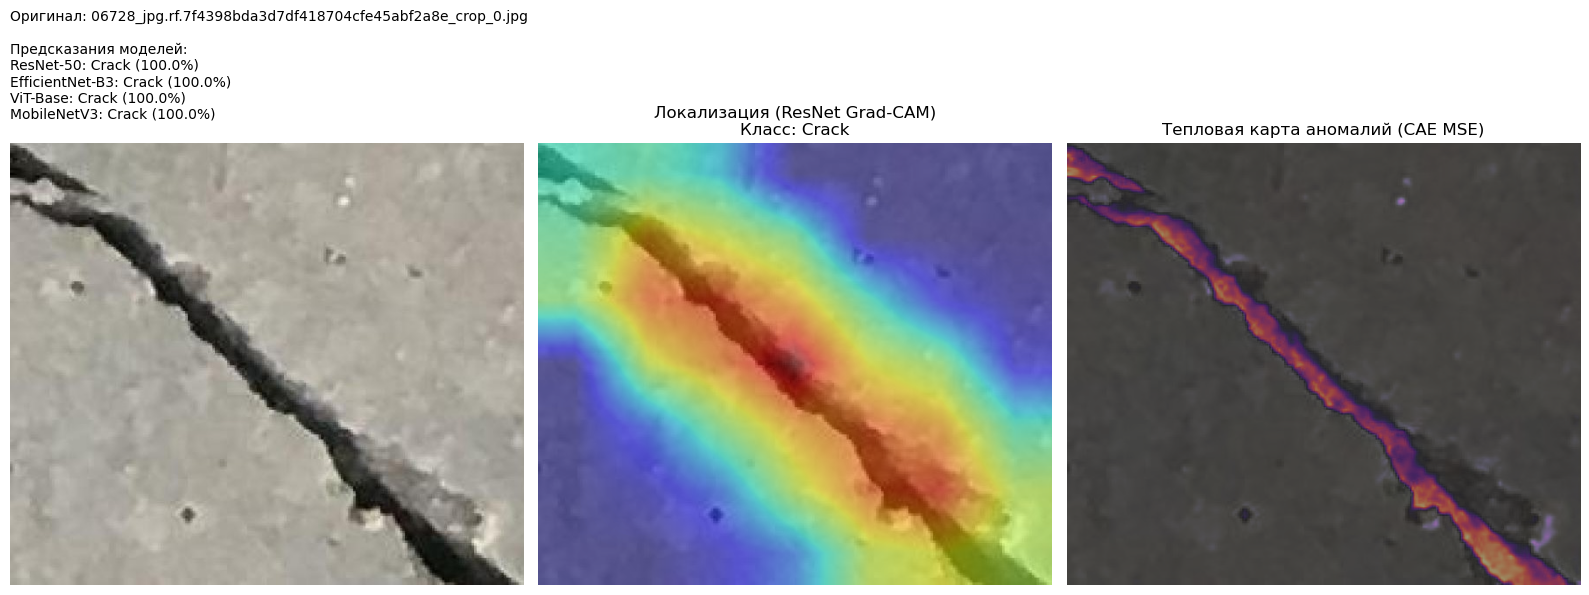

In [31]:
# Демонстрационный модуль и логирование
def inspection_demo_pipeline(image_path, clf_models, anomaly_model):
    img_pil = Image.open(image_path).convert("RGB")
    img_tensor = val_test_transform(img_pil).unsqueeze(0).to(device)
    
    preds_text = "Предсказания моделей:\n"
    resnet_heatmap = None
    resnet_conf = 0
    resnet_class = ""

    # 1. Классификация всеми моделями
    for name, model in clf_models.items():
        model.eval()
        
        # Для ResNet-50 дополнительно строим Grad-CAM
        if name == 'ResNet-50':
            heatmap_clf, class_idx = model.generate_heatmap(img_tensor)
            resnet_heatmap = heatmap_clf
            confidence = torch.max(F.softmax(model(img_tensor), dim=1)).item() * 100
            resnet_conf = confidence
            resnet_class = CLASSES_STR[class_idx]
            preds_text += f"{name}: {resnet_class} ({confidence:.1f}%)\n"
        else:
            with torch.no_grad():
                logits = model(img_tensor)
                confidence = torch.max(F.softmax(logits, dim=1)).item() * 100
                class_idx = torch.argmax(logits, dim=1).item()
                preds_text += f"{name}: {CLASSES_STR[class_idx]} ({confidence:.1f}%)\n"
    
    # 2. Anomaly Detection (CAE)
    anomaly_model.eval()
    with torch.no_grad():
        reconstructed = anomaly_model(img_tensor)
        heatmap_cae = compute_cae_heatmap(img_tensor, reconstructed)[0]
    
    # Нормализация CAE тепловой карты для отрисовки
    heatmap_cae = (heatmap_cae - heatmap_cae.min()) / (heatmap_cae.max() - heatmap_cae.min() + 1e-8)

    # Визуализация 1: Оригинал с предсказаниями, 2: Grad-CAM (Классификатор), 3: CAE Heatmap (Аномалии)
    fig, axes = plt.subplots(1, 3, figsize=(16, 6))
    axes[0].imshow(img_pil)
    axes[0].set_title(f"Оригинал: {os.path.basename(image_path)}\n\n{preds_text}", fontsize=10, loc='left')
    
    axes[1].imshow(img_pil)
    if resnet_heatmap is not None:
        axes[1].imshow(cv2.resize(resnet_heatmap, (img_pil.width, img_pil.height)), cmap='jet', alpha=0.5)
    axes[1].set_title(f"Локализация (ResNet Grad-CAM)\nКласс: {resnet_class}")
    
    axes[2].imshow(img_pil)
    axes[2].imshow(cv2.resize(heatmap_cae, (img_pil.width, img_pil.height)), cmap='magma', alpha=0.6)
    axes[2].set_title("Тепловая карта аномалий (CAE MSE)")
    
    for ax in axes: ax.axis('off')
    plt.tight_layout()
    plt.show()

    # Сохранение лога в JSON
    log_record = {"time": str(datetime.datetime.now()), "file": os.path.basename(image_path), "class": resnet_class, "conf": float(resnet_conf)}
    logs = json.load(open("logs.json", "r")) if os.path.exists("logs.json") else []
    logs.append(log_record)
    json.dump(logs, open("logs.json", "w"), indent=4)


demo_resnet = ResNet50GradCAM(5).to(device)
demo_resnet.load_state_dict(torch.load("resnet50_best.pth"))

demo_effnet = EfficientNetB3Model(5).to(device)
demo_effnet.load_state_dict(torch.load("effnet_b3_best.pth"))

demo_vit = ViTBaseModel(5).to(device)
demo_vit.load_state_dict(torch.load("vit_base_best.pth"))

demo_mobilenet = MobileNetV3Model(5).to(device)
demo_mobilenet.load_state_dict(torch.load("mobilenet_v3_best.pth"))

clf_models_dict = {
    'ResNet-50': demo_resnet,
    'EfficientNet-B3': demo_effnet,
    'ViT-Base': demo_vit,
    'MobileNetV3': demo_mobilenet
}

demo_cae = ConvAutoencoder().to(device)
demo_cae.load_state_dict(torch.load("cae_best.pth"))

test_images = [os.path.join('./dataset/y5uul/test/Crack', f) for f in os.listdir('./dataset/y5uul/test/Crack')[:2]]
for img_path in test_images:
    inspection_demo_pipeline(img_path, clf_models_dict, demo_cae)


In [42]:
import sys
!{sys.executable} -m pip install openpyxl


   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   ---------------------------------------- 2/2 [openpyxl]



In [33]:
# Анализ ошибок и экспорт
print("\nГенерация отчета и выгрузка")
if os.path.exists("logs.json"):
    df = pd.DataFrame(json.load(open("logs.json", "r")))
    df.to_excel("production_report.xlsx", index=False)
    print("Отчет Excel успешно сохранен как: production_report.xlsx")
    print("Матрицы ошибок сохранены в корневую папку как cm_*.png")


Генерация отчета и выгрузка
Отчет Excel успешно сохранен как: production_report.xlsx
Матрицы ошибок сохранены в корневую папку как cm_*.png



Анализ ошибок лучшей модели (на примере EfficientNet-B3)

Примеры успешной работы модели


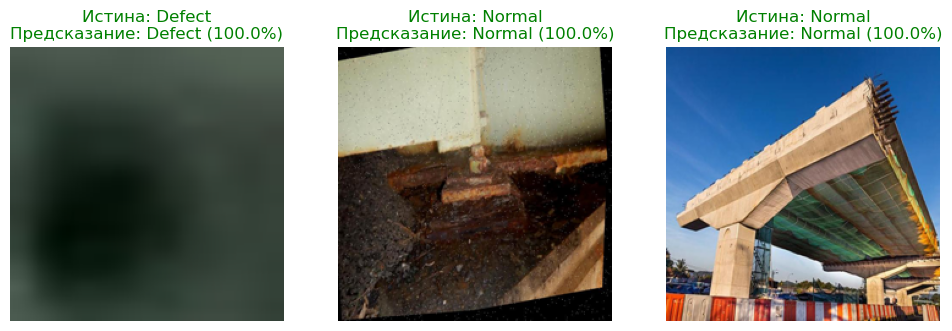


Примеры ошибок (ложные срабатывания/пропуски)


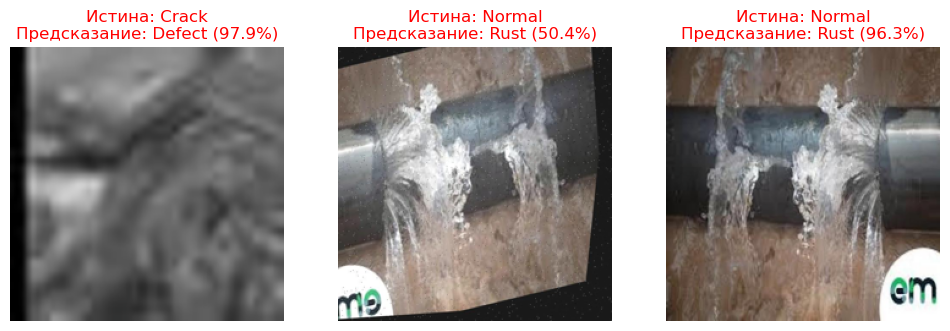

In [35]:
#Визуальный анализ успехов и ошибок
def analyze_model_errors(model, evaluation_loader, classes):
    model.eval()
    successes, errors = [], []
    
    with torch.no_grad():
        for inputs, labels in evaluation_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            probs = F.softmax(model(inputs), dim=1)
            confs, preds = torch.max(probs, 1)
            
            for i in range(inputs.size(0)):
                item = (inputs[i].cpu(), classes[labels[i].item()], classes[preds[i].item()], confs[i].item()*100)
                if preds[i] == labels[i] and len(successes) < 3: successes.append(item)
                elif preds[i] != labels[i] and len(errors) < 3: errors.append(item)
                if len(successes) == 3 and len(errors) == 3: break
            if len(successes) == 3 and len(errors) == 3: break

    print("\nПримеры успешной работы модели")
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for idx, (img_t, true_c, pred_c, conf) in enumerate(successes):
        axes[idx].imshow(unnormalize(img_t).permute(1, 2, 0).numpy())
        axes[idx].set_title(f"Истина: {true_c}\nПредсказание: {pred_c} ({conf:.1f}%)", color='green')
        axes[idx].axis('off')
    plt.show()

    print("\nПримеры ошибок (ложные срабатывания/пропуски)")
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for idx, (img_t, true_c, pred_c, conf) in enumerate(errors):
        axes[idx].imshow(unnormalize(img_t).permute(1, 2, 0).numpy())
        axes[idx].set_title(f"Истина: {true_c}\nПредсказание: {pred_c} ({conf:.1f}%)", color='red')
        axes[idx].axis('off')
    plt.show()

print("\nАнализ ошибок лучшей модели (на примере EfficientNet-B3)")
best_demo_model = EfficientNetB3Model(5).to(device)
best_demo_model.load_state_dict(torch.load("effnet_b3_best.pth"))
# 🚀 ИСПРАВЛЕНИЕ: Используем val_loader вместо test_loader, чтобы избежать ошибок грязной разметки
analyze_model_errors(best_demo_model, val_loader, CLASSES_STR)
del best_demo_model; gc.collect(); torch.cuda.empty_cache()